# 10 RMSFE、最低误差基准与预测误差时序

本 Notebook 只完成清单第 10 项：严格读取 README 固定且已经验收的第 09 项预测成果，在样本外目标日从正式 silver 重新计算三类真实方差代理，计算 Table 7 风格 RMSFE，选择每个“研究序列 × 方差代理”的最低误差基准，并绘制 Figure 2 风格预测误差图。

## 1. 在做什么，以及经济意义

方差预测无法直接与不可观测的真实条件方差比较，因此论文分别使用五分钟实现方差、median-based 方差和 Parkinson 区间方差作为真实方差代理。RMSFE 衡量模型预测偏离代理的典型幅度；数值越小，说明该模型在相同样本外日期上对次日日盘方差的预测越准确。

经济上，本项回答三个问题：日内 GARCH 模型是否真的优于日频模型；长记忆 ARFIMA 是否具有稳定优势；模型排名是否依赖所选真实方差代理。RB 是论文外扩展，FU 两个制度阶段始终分开。

## 2. 论文公式、表图对应和代码步骤

论文公式 (7)：

$$
\operatorname{RMSFE}_m =
\sqrt{\frac{1}{R}\sum_{t=1}^{R}
\left(\hat h_{m,t+1}-\hat\sigma^2_{t+1}\right)^2}.
$$

其中 $\hat h_{m,t+1}$ 是模型 $m$ 的次日方差预测，$\hat\sigma^2_{t+1}$ 是选定的真实方差代理。本 Notebook 把结果乘以 $10^5$ 展示，以对应论文 Table 7 的报告尺度，但计算和排序始终使用未缩放方差。

Figure 2 风格有符号误差定义为 `真实方差代理 - 预测方差`。负值表示模型高估代理方差；平方损失不受符号选择影响。论文图比较 median-based 方差代理下的 30 分钟 ARFIMA 与 30 分钟 GARCH。

代码从上到下分为七步：

1. 验证固定 Item 09 run 的 `_SUCCESS`、manifest、文件哈希、Schema 指纹和上游门禁。
2. 从预测面板取得 1,300 个样本外目标日与固定三个月合约。
3. 直接过滤读取合约 Session、分钟日历和分钟事实。
4. 在每个真实 Session 开盘锚定收益，并重新计算 RV、MedRV、Parkinson。
5. 将三个代理与 24 个预测序列连接，形成有符号误差和平方损失面板。
6. 以 15 个论文基线模型计算 Table 7 风格 RMSFE 和最低误差基准；9 个无前视季节因子模型单独报告敏感性。
7. 绘制 Figure 2 风格时序并执行独立手工复核与完整门禁。

复现等级是论文方法框架复现，不是 GTA 原数值复制。

In [1]:
from __future__ import annotations

from datetime import date
import gc
import hashlib
import json
import pathlib
import re
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path(r"E:\anaconda3\envs\latitude\python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude 环境解释器 {expected_python}，实际为 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from IPython.display import Markdown, display

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from config.notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")

project_dir = (
    project_root
    / "01_project_collection"
    / "china_commodity_futures_intraday_volatility_forecasting_reproduction"
)

print(f"Python: {sys.executable}")
print(f"项目根目录: {project_root}")
print(f"研究项目目录: {project_dir}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
项目根目录: E:\Latitude_Analytics_v2
研究项目目录: E:\Latitude_Analytics_v2\01_project_collection\china_commodity_futures_intraday_volatility_forecasting_reproduction
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

In [2]:
display_schema_metadata(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与固定成果身份

In [3]:
exchange_code = "XSGE"
expected_day_sessions = 3
expected_day_minutes = 225
five_minute_interval = 5
expected_five_minute_slots = 45
expected_medrv_terms = expected_five_minute_slots - 2
zero_return_tolerance = 1e-12

medrv_consistency_constant = np.pi / (6 - 4 * np.sqrt(3) + np.pi)
medrv_finite_sample_multiplier = expected_five_minute_slots / expected_medrv_terms
medrv_total_multiplier = medrv_consistency_constant * medrv_finite_sample_multiplier

fixed_run_id = "eaf4757d3488c2b7"
fixed_run_fingerprint = (
    "eaf4757d3488c2b74f1e81fa558d8146"
    "cdee562836f7fd4084b32ac7ca6fdec6"
)
expected_artifact_contract_version = "item09-rolling-forecast-stream-v1"
expected_storage_layout = "flat-v2"
artifact_run_dir = project_dir / "data" / "item09" / fixed_run_id

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), 200, "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), 200, "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), 300, "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "oos_days",
        "research_role",
    ],
)
for date_column in ["sample_start", "sample_end"]:
    sample_spec_df[date_column] = pd.to_datetime(sample_spec_df[date_column])

series_order = sample_spec_df["series_id"].tolist()
proxy_spec = [
    ("realized_variance", "RV_5min", "Panel A: 5-min realized variance"),
    ("median_based_variance", "MedRV", "Panel B: median-based variance"),
    ("range_based_variance", "Parkinson", "Panel C: range-based variance"),
]
proxy_order = [proxy_id for _, proxy_id, _ in proxy_spec]
proxy_panel_label = {proxy_id: label for _, proxy_id, label in proxy_spec}

display(sample_spec_df)
display(
    pd.DataFrame(
        {
            "parameter": [
                "fixed_run_id",
                "fixed_run_fingerprint",
                "artifact_contract_version",
                "storage_layout",
                "five_minute_slots",
                "MedRV terms",
                "MedRV total multiplier",
            ],
            "value": [
                fixed_run_id,
                fixed_run_fingerprint,
                expected_artifact_contract_version,
                expected_storage_layout,
                expected_five_minute_slots,
                expected_medrv_terms,
                medrv_total_multiplier,
            ],
        }
    )
)

,series_id,underlying_code,sample_start,sample_end,oos_days,research_role
0,AL,AL,2010-01-04,2026-08-28,300,论文品种
1,CU,CU,2010-01-04,2026-08-28,300,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,200,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,200,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,300,论文外扩展品种


,parameter,value
0,fixed_run_id,eaf4757d3488c2b7
1,fixed_run_fingerprint,eaf4757d3488c2b74f1e81fa558d8146cdee562836f7fd4084b32ac7ca6fdec6
2,artifact_contract_version,item09-rolling-forecast-stream-v1
3,storage_layout,flat-v2
4,five_minute_slots,45
5,MedRV terms,43
6,MedRV total multiplier,1.485375


## 5. 固定 Item 09 成果的完整性验证与预测读取

In [4]:
def sha256_file(file_path):
    file_hasher = hashlib.sha256()
    with pathlib.Path(file_path).open("rb") as binary_stream:
        for file_chunk in iter(lambda: binary_stream.read(1024 * 1024), b""):
            file_hasher.update(file_chunk)
    return file_hasher.hexdigest()


readme_text = (project_dir / "README.md").read_text(encoding="utf-8")
fixed_run_match = re.search(
    r"当前固定且已完整验收.*?run_id.*?\*\*`([0-9a-f]{16})`\*\*",
    readme_text,
    flags=re.DOTALL,
)
assert fixed_run_match is not None
assert fixed_run_match.group(1) == fixed_run_id
assert f"**`{fixed_run_fingerprint}`**" in readme_text

success_path = artifact_run_dir / "_SUCCESS.json"
manifest_path = artifact_run_dir / "manifest.json"
assert success_path.is_file() and manifest_path.is_file(), artifact_run_dir

success_payload = json.loads(success_path.read_text(encoding="utf-8"))
manifest_payload = json.loads(manifest_path.read_text(encoding="utf-8"))
assert success_payload["artifact_contract_version"] == expected_artifact_contract_version
assert success_payload["storage_layout"] == expected_storage_layout
assert success_payload["run_id"] == fixed_run_id
assert success_payload["run_fingerprint"] == fixed_run_fingerprint
assert success_payload["manifest_sha256"] == sha256_file(manifest_path)
assert manifest_payload["status"] == "complete"
assert manifest_payload["artifact_contract_version"] == expected_artifact_contract_version
assert manifest_payload["storage_layout"] == expected_storage_layout
assert manifest_payload["run_id"] == fixed_run_id
assert manifest_payload["run_fingerprint"] == fixed_run_fingerprint
assert manifest_payload["expected_streams"] == 120
assert manifest_payload["expected_forecast_rows"] == 31_200
assert manifest_payload["expected_step_rows"] == 214_500

artifact_file_audit_rows = []
artifact_file_record_by_role = {}
for file_record in manifest_payload["consolidated_files"]:
    artifact_role = file_record["artifact_role"]
    artifact_file_record_by_role[artifact_role] = file_record
    artifact_file_path = artifact_run_dir / file_record["relative_path"]
    actual_schema = pq.read_schema(artifact_file_path).remove_metadata()
    actual_schema_fingerprint = hashlib.sha256(
        actual_schema.serialize().to_pybytes()
    ).hexdigest()
    actual_metadata = pq.read_metadata(artifact_file_path)
    file_passed = (
        artifact_file_path.is_file()
        and artifact_file_path.stat().st_size == file_record["bytes"]
        and sha256_file(artifact_file_path) == file_record["sha256"]
        and actual_schema.names == file_record["columns"]
        and actual_schema_fingerprint == file_record["schema_fingerprint"]
        and actual_metadata.num_rows == file_record["rows"]
    )
    artifact_file_audit_rows.append(
        {
            "artifact_role": artifact_role,
            "relative_path": file_record["relative_path"],
            "rows": actual_metadata.num_rows,
            "bytes": artifact_file_path.stat().st_size,
            "integrity_passed": file_passed,
        }
    )
assert set(artifact_file_record_by_role) == {
    "forecast_panel",
    "forecast_steps",
    "stream_summary",
    "validation_gates",
}
artifact_file_audit_df = pd.DataFrame(artifact_file_audit_rows)
assert artifact_file_audit_df["integrity_passed"].all()

validation_gate_path = (
    artifact_run_dir
    / artifact_file_record_by_role["validation_gates"]["relative_path"]
)
upstream_validation_df = pq.read_table(validation_gate_path).to_pandas()
assert len(upstream_validation_df) == manifest_payload["validation_gate_count"] == 27
assert upstream_validation_df["passed"].all()

forecast_columns = [
    "series_id",
    "forecast_origin_date",
    "forecast_date",
    "model_id",
    "model_class",
    "model_family",
    "interval_label",
    "seasonality_variant",
    "is_primary",
    "uses_forward_seasonality",
    "model_information_end",
    "seasonality_information_end",
    "forecast_variance",
    "fit_success",
    "target_contract_code",
    "underlying_code",
    "target_is_roll_day",
    "origin_contract_code",
]
forecast_panel_path = (
    artifact_run_dir
    / artifact_file_record_by_role["forecast_panel"]["relative_path"]
)
forecast_panel_df = pq.read_table(
    forecast_panel_path,
    columns=forecast_columns,
).to_pandas()
for date_column in [
    "forecast_origin_date",
    "forecast_date",
    "model_information_end",
    "seasonality_information_end",
]:
    forecast_panel_df[date_column] = pd.to_datetime(forecast_panel_df[date_column])
forecast_panel_df = forecast_panel_df.sort_values(
    ["series_id", "forecast_date", "model_id"],
    ignore_index=True,
)

assert len(forecast_panel_df) == 31_200
assert not forecast_panel_df.duplicated(
    ["series_id", "forecast_date", "model_id"]
).any()
assert forecast_panel_df["fit_success"].all()
assert np.isfinite(forecast_panel_df["forecast_variance"]).all()
assert forecast_panel_df["forecast_variance"].gt(0).all()

display(artifact_file_audit_df)
display(
    forecast_panel_df.groupby(
        ["series_id", "is_primary"], observed=True
    ).agg(
        forecast_rows=("model_id", "size"),
        model_count=("model_id", "nunique"),
        target_days=("forecast_date", "nunique"),
        first_target=("forecast_date", "min"),
        last_target=("forecast_date", "max"),
    ).reset_index()
)

,artifact_role,relative_path,rows,bytes,integrity_passed
0,forecast_panel,forecast_panel.parquet,31200,5423310,True
1,forecast_steps,forecast_steps.parquet,214500,4235533,True
2,stream_summary,stream_summary.parquet,120,8701,True
3,validation_gates,validation_gates.parquet,27,4415,True


,series_id,is_primary,forecast_rows,model_count,target_days,first_target,last_target
0,AL,False,2700,9,300,2025-06-10,2026-08-28
1,AL,True,4500,15,300,2025-06-10,2026-08-28
2,CU,False,2700,9,300,2025-06-10,2026-08-28
3,CU,True,4500,15,300,2025-06-10,2026-08-28
4,FU_legacy,False,1800,9,200,2010-12-10,2011-09-30
5,FU_legacy,True,3000,15,200,2010-12-10,2011-09-30
6,FU_relaunched,False,1800,9,200,2025-11-05,2026-08-28
7,FU_relaunched,True,3000,15,200,2025-11-05,2026-08-28
8,RB,False,2700,9,300,2025-06-10,2026-08-28
9,RB,True,4500,15,300,2025-06-10,2026-08-28


## 6. 正式 silver 数据集与样本外固定三个月合约

In [5]:
source_schema_by_role = {
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
1,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
2,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [6]:
target_consistency_df = (
    forecast_panel_df.groupby(
        ["series_id", "forecast_date"], observed=True, sort=True
    )
    .agg(
        target_contract_count=("target_contract_code", "nunique"),
        underlying_count=("underlying_code", "nunique"),
        roll_flag_count=("target_is_roll_day", "nunique"),
        origin_contract_count=("origin_contract_code", "nunique"),
    )
    .reset_index()
)
assert target_consistency_df[
    [
        "target_contract_count",
        "underlying_count",
        "roll_flag_count",
        "origin_contract_count",
    ]
].eq(1).all().all()

target_day_df = (
    forecast_panel_df.groupby(
        ["series_id", "forecast_date"], observed=True, sort=True
    )
    .agg(
        target_contract_code=("target_contract_code", "first"),
        underlying_code=("underlying_code", "first"),
        target_is_roll_day=("target_is_roll_day", "first"),
        origin_contract_code=("origin_contract_code", "first"),
    )
    .reset_index()
    .merge(
        sample_spec_df,
        on=["series_id", "underlying_code"],
        how="left",
        validate="many_to_one",
    )
)
assert len(target_day_df) == int(sample_spec_df["oos_days"].sum()) == 1_300
assert target_day_df["research_role"].notna().all()

target_contract_parts = target_day_df["target_contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
assert target_contract_parts.notna().all().all()
target_day_df["code_underlying"] = target_contract_parts[0]
target_day_df["delivery_year"] = 2000 + target_contract_parts[1].str[:2].astype("int16")
target_day_df["delivery_month"] = target_contract_parts[1].str[2:].astype("int8")
target_day_df["code_exchange"] = target_contract_parts[2]
target_delivery_period = pd.PeriodIndex(target_day_df["forecast_date"], freq="M") + 3
assert target_day_df["code_underlying"].eq(target_day_df["underlying_code"]).all()
assert target_day_df["code_exchange"].eq(exchange_code).all()
assert target_day_df["delivery_year"].eq(target_delivery_period.year).all()
assert target_day_df["delivery_month"].eq(target_delivery_period.month).all()

oos_date_audit_df = (
    target_day_df.groupby("series_id", observed=True)
    .agg(
        oos_days=("forecast_date", "size"),
        first_oos_date=("forecast_date", "min"),
        last_oos_date=("forecast_date", "max"),
        target_contracts=("target_contract_code", "nunique"),
        roll_days=("target_is_roll_day", "sum"),
    )
    .reset_index()
    .merge(
        sample_spec_df[["series_id", "sample_end", "oos_days"]].rename(
            columns={"oos_days": "expected_oos_days"}
        ),
        on="series_id",
        validate="one_to_one",
    )
)
assert oos_date_audit_df["oos_days"].eq(oos_date_audit_df["expected_oos_days"]).all()
assert oos_date_audit_df["last_oos_date"].eq(oos_date_audit_df["sample_end"]).all()

oos_filter = None
for sample_spec in sample_spec_df.itertuples(index=False):
    series_target_dates = target_day_df.loc[
        target_day_df["series_id"].eq(sample_spec.series_id),
        "forecast_date",
    ]
    series_filter = (
        (ds.field("underlying_code") == sample_spec.underlying_code)
        & (ds.field("year") >= int(series_target_dates.min().year))
        & (ds.field("year") <= int(series_target_dates.max().year))
        & (
            ds.field("trading_date")
            >= pa.scalar(series_target_dates.min().date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(series_target_dates.max().date(), type=pa.date32())
        )
    )
    oos_filter = series_filter if oos_filter is None else (oos_filter | series_filter)

contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name) for column_name in contract_columns]
)
contract_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=(ds.field("exchange_code") == exchange_code)
    & (ds.field("is_night_session") == False)
    & oos_filter,
)
validated_contract_table = validate_arrow_table(
    contract_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)
assert not contract_calendar_df["is_night_session"].any()

target_contract_key_df = target_day_df.rename(
    columns={"forecast_date": "trading_date"}
)[
    [
        "series_id",
        "trading_date",
        "target_contract_code",
        "underlying_code",
        "target_is_roll_day",
    ]
].rename(columns={"target_contract_code": "contract_code"})
selected_target_session_df = target_contract_key_df.merge(
    contract_calendar_df,
    on=["contract_code", "underlying_code", "trading_date"],
    how="left",
    validate="one_to_many",
)
assert selected_target_session_df["session_number"].notna().all()

target_session_audit_df = (
    selected_target_session_df.groupby(
        ["series_id", "trading_date", "contract_code"], observed=True
    )
    .agg(
        session_count=("session_number", "nunique"),
        minute_count=("minute_count", "sum"),
        night_sessions=("is_night_session", "sum"),
    )
    .reset_index()
)
assert len(target_session_audit_df) == 1_300
assert target_session_audit_df["session_count"].eq(expected_day_sessions).all()
assert target_session_audit_df["minute_count"].eq(expected_day_minutes).all()
assert target_session_audit_df["night_sessions"].eq(0).all()

display(oos_date_audit_df)
display(target_session_audit_df.groupby("series_id", observed=True).agg(
    contract_days=("trading_date", "size"),
    sessions=("session_count", "sum"),
    expected_minutes=("minute_count", "sum"),
).reset_index())

,series_id,oos_days,first_oos_date,last_oos_date,target_contracts,roll_days,sample_end,expected_oos_days
0,AL,300,2025-06-10,2026-08-28,15,14,2026-08-28,300
1,CU,300,2025-06-10,2026-08-28,15,14,2026-08-28,300
2,FU_legacy,200,2010-12-10,2011-09-30,10,9,2011-09-30,200
3,FU_relaunched,200,2025-11-05,2026-08-28,10,9,2026-08-28,200
4,RB,300,2025-06-10,2026-08-28,15,14,2026-08-28,300


,series_id,contract_days,sessions,expected_minutes
0,AL,300,900,67500
1,CU,300,900,67500
2,FU_legacy,200,600,45000
3,FU_relaunched,200,600,45000
4,RB,300,900,67500


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
bar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=(ds.field("exchange_code") == exchange_code)
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
    & oos_filter,
)
validated_bar_table = validate_arrow_table(bar_table, bar_projection_schema)
bar_calendar_df = arrow_to_pandas(validated_bar_table, bar_projection_schema)
bar_calendar_df["trading_date"] = pd.to_datetime(bar_calendar_df["trading_date"])

session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df.merge(
    bar_calendar_df,
    on=session_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)
assert selected_bar_session_df["eligible_session"].all()

bar_day_audit_df = (
    selected_bar_session_df.groupby(
        ["series_id", "trading_date", "contract_code"], observed=True
    )
    .agg(
        session_rows=("session_number", "size"),
        eligible_sessions=("eligible_session", "sum"),
        expected_minutes=("expected_bar_count", "sum"),
        actual_minutes=("actual_bar_count", "sum"),
        missing_minutes=("missing_bar_count", "sum"),
    )
    .reset_index()
)
assert bar_day_audit_df["session_rows"].eq(expected_day_sessions).all()
assert bar_day_audit_df["eligible_sessions"].eq(expected_day_sessions).all()
assert bar_day_audit_df["expected_minutes"].eq(expected_day_minutes).all()
assert bar_day_audit_df["actual_minutes"].eq(expected_day_minutes).all()
assert bar_day_audit_df["missing_minutes"].eq(0).all()

complete_session_keys_df = selected_bar_session_df.loc[
    selected_bar_session_df["eligible_session"],
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "target_is_roll_day",
        "expected_bar_count",
    ],
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

display(
    bar_day_audit_df.groupby("series_id", observed=True).agg(
        contract_days=("trading_date", "size"),
        eligible_sessions=("eligible_sessions", "sum"),
        expected_minutes=("expected_minutes", "sum"),
        actual_minutes=("actual_minutes", "sum"),
    ).reset_index()
)

,series_id,contract_days,eligible_sessions,expected_minutes,actual_minutes
0,AL,300,900,67500,67500
1,CU,300,900,67500,67500
2,FU_legacy,200,600,45000,45000
3,FU_relaunched,200,600,45000,45000
4,RB,300,900,67500,67500


## 7. 样本外三类真实方差代理的直接重算

In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "high",
    "low",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "target_is_roll_day",
    "expected_bar_count",
]
daily_group_key = [
    "series_id",
    "contract_code",
    "underlying_code",
    "trading_date",
    "target_is_roll_day",
]

daily_proxy_pieces = []
minute_read_audit_rows = []

for (series_id, calendar_year), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"], observed=True, sort=True
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(minute_session_join_key).any()

    underlying_codes = partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = partition_session_keys_df["contract_code"].drop_duplicates().tolist()

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    ).sort_values(
        ["series_id", "trading_date", "contract_code", "bar_at"],
        ignore_index=True,
    )
    for price_column in ["open", "high", "low", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    observed_session_rows_df = (
        selected_minute_df.groupby(minute_session_join_key, observed=True, sort=False)
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        session_alignment_df["expected_bar_count"].ne(
            session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key, observed=True, sort=False
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key, observed=True, sort=False
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df["minute_position_within_session"].eq(1)
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    valid_return_mask = (
        np.isfinite(selected_minute_df["return_reference_price"])
        & selected_minute_df["return_reference_price"].gt(0)
        & np.isfinite(selected_minute_df["close"])
        & selected_minute_df["close"].gt(0)
    )
    valid_range_mask = (
        np.isfinite(selected_minute_df["high"])
        & selected_minute_df["high"].gt(0)
        & np.isfinite(selected_minute_df["low"])
        & selected_minute_df["low"].gt(0)
    )
    selected_minute_df["source_high_below_low"] = (
        valid_range_mask
        & selected_minute_df["high"].lt(selected_minute_df["low"])
    )
    assert valid_return_mask.all()
    assert valid_range_mask.all()
    assert not selected_minute_df["source_high_below_low"].any()

    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(daily_group_key, observed=True, sort=False).cumcount()
        + 1
    )
    selected_minute_df["five_minute_slot"] = (
        (selected_minute_df["trading_minute_ordinal"] - 1) // five_minute_interval
        + 1
    )

    five_minute_df = (
        selected_minute_df.groupby(
            daily_group_key + ["five_minute_slot"],
            observed=True,
            sort=True,
        )
        .agg(
            five_minute_return=("minute_log_return", "sum"),
            actual_interval_minutes=("minute_log_return", "size"),
            session_span_count=("session_number", "nunique"),
        )
        .reset_index()
        .sort_values(daily_group_key + ["five_minute_slot"], ignore_index=True)
    )
    five_minute_df["squared_return"] = five_minute_df["five_minute_return"] ** 2
    five_minute_df["absolute_return"] = five_minute_df["five_minute_return"].abs()
    daily_five_minute_group = five_minute_df.groupby(
        daily_group_key, observed=True, sort=False
    )
    five_minute_df["previous_absolute_return"] = daily_five_minute_group[
        "absolute_return"
    ].shift()
    five_minute_df["next_absolute_return"] = daily_five_minute_group[
        "absolute_return"
    ].shift(-1)
    five_minute_df["three_return_median"] = five_minute_df[
        ["previous_absolute_return", "absolute_return", "next_absolute_return"]
    ].median(axis=1, skipna=False)
    five_minute_df["median_triplet_squared"] = (
        five_minute_df["three_return_median"] ** 2
    )

    five_minute_day_audit_df = (
        five_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            five_minute_slots=("five_minute_slot", "size"),
            aggregated_minutes=("actual_interval_minutes", "sum"),
            minimum_interval_minutes=("actual_interval_minutes", "min"),
            maximum_interval_minutes=("actual_interval_minutes", "max"),
            maximum_session_span=("session_span_count", "max"),
            median_term_count=("median_triplet_squared", "count"),
        )
        .reset_index()
    )
    assert five_minute_day_audit_df["five_minute_slots"].eq(
        expected_five_minute_slots
    ).all()
    assert five_minute_day_audit_df["aggregated_minutes"].eq(
        expected_day_minutes
    ).all()
    assert five_minute_day_audit_df["minimum_interval_minutes"].eq(5).all()
    assert five_minute_day_audit_df["maximum_interval_minutes"].eq(5).all()
    assert five_minute_day_audit_df["maximum_session_span"].eq(1).all()
    assert five_minute_day_audit_df["median_term_count"].eq(
        expected_medrv_terms
    ).all()

    daily_return_proxy_df = (
        five_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            five_minute_return_count=("five_minute_return", "size"),
            realized_variance=("squared_return", "sum"),
            medrv_core_sum=("median_triplet_squared", "sum"),
            median_term_count=("median_triplet_squared", "count"),
        )
        .reset_index()
    )
    daily_return_proxy_df["median_based_variance"] = (
        medrv_total_multiplier * daily_return_proxy_df["medrv_core_sum"]
    )

    daily_range_df = (
        selected_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            minute_rows=("bar_at", "size"),
            daily_high=("high", "max"),
            daily_low=("low", "min"),
            source_high_below_low_rows=("source_high_below_low", "sum"),
        )
        .reset_index()
    )
    assert daily_range_df["minute_rows"].eq(expected_day_minutes).all()
    assert daily_range_df["daily_high"].ge(daily_range_df["daily_low"]).all()
    daily_range_df["range_based_variance"] = (
        np.log(daily_range_df["daily_high"] / daily_range_df["daily_low"]) ** 2
        / (4 * np.log(2))
    )
    daily_proxy_df = daily_return_proxy_df.merge(
        daily_range_df,
        on=daily_group_key,
        how="inner",
        validate="one_to_one",
    )
    daily_proxy_pieces.append(daily_proxy_df)
    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": len(daily_proxy_df),
            "five_minute_return_rows": len(five_minute_df),
            "maximum_session_span": int(
                five_minute_day_audit_df["maximum_session_span"].max()
            ),
            "source_high_below_low_rows": int(
                daily_range_df["source_high_below_low_rows"].sum()
            ),
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        five_minute_df,
        five_minute_day_audit_df,
        daily_return_proxy_df,
        daily_range_df,
        daily_proxy_df,
    )
    gc.collect()

volatility_proxy_df = pd.concat(daily_proxy_pieces, ignore_index=True).sort_values(
    ["series_id", "trading_date"], ignore_index=True
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)

assert len(volatility_proxy_df) == 1_300
assert not volatility_proxy_df.duplicated(["series_id", "trading_date"]).any()
for proxy_column, _, _ in proxy_spec:
    assert np.isfinite(volatility_proxy_df[proxy_column]).all()
    assert volatility_proxy_df[proxy_column].ge(0).all()

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        five_minute_return_rows=("five_minute_return_rows", "sum"),
        maximum_session_span=("maximum_session_span", "max"),
        source_high_below_low_rows=("source_high_below_low_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,five_minute_return_rows,maximum_session_span,source_high_below_low_rows,elapsed_seconds
0,AL,2,839940,67500,67500,0,900,300,13500,1,0,1.977
1,CU,2,839940,67500,67500,0,900,300,13500,1,0,1.955
2,FU_legacy,2,275175,45000,45000,0,600,200,9000,1,0,0.908
3,FU_relaunched,2,355410,45000,45000,0,600,200,9000,1,0,1.013
4,RB,2,625620,67500,67500,0,900,300,13500,1,0,1.588


## 8. 预测误差面板、RMSFE 与最低误差基准

In [9]:
proxy_for_merge_df = volatility_proxy_df[
    [
        "series_id",
        "trading_date",
        "contract_code",
        "target_is_roll_day",
        "realized_variance",
        "median_based_variance",
        "range_based_variance",
    ]
].rename(
    columns={
        "trading_date": "forecast_date",
        "contract_code": "proxy_contract_code",
        "target_is_roll_day": "proxy_is_roll_day",
    }
)
forecast_with_proxy_df = forecast_panel_df.merge(
    proxy_for_merge_df,
    on=["series_id", "forecast_date"],
    how="left",
    validate="many_to_one",
)
assert forecast_with_proxy_df[
    ["realized_variance", "median_based_variance", "range_based_variance"]
].notna().all().all()
assert forecast_with_proxy_df["target_contract_code"].eq(
    forecast_with_proxy_df["proxy_contract_code"]
).all()
assert forecast_with_proxy_df["target_is_roll_day"].eq(
    forecast_with_proxy_df["proxy_is_roll_day"]
).all()

loss_panel_pieces = []
loss_identity_columns = [
    "series_id",
    "forecast_origin_date",
    "forecast_date",
    "model_id",
    "model_class",
    "model_family",
    "interval_label",
    "seasonality_variant",
    "is_primary",
    "uses_forward_seasonality",
    "forecast_variance",
    "target_contract_code",
    "target_is_roll_day",
]
for proxy_column, proxy_id, panel_label in proxy_spec:
    proxy_loss_df = forecast_with_proxy_df[
        loss_identity_columns + [proxy_column]
    ].rename(columns={proxy_column: "true_variance"})
    proxy_loss_df["proxy_id"] = proxy_id
    proxy_loss_df["proxy_panel"] = panel_label
    proxy_loss_df["forecast_error"] = (
        proxy_loss_df["true_variance"] - proxy_loss_df["forecast_variance"]
    )
    proxy_loss_df["squared_forecast_error"] = (
        proxy_loss_df["forecast_error"] ** 2
    )
    loss_panel_pieces.append(proxy_loss_df)

loss_panel_df = pd.concat(loss_panel_pieces, ignore_index=True).sort_values(
    ["proxy_id", "series_id", "forecast_date", "model_id"],
    ignore_index=True,
)
primary_loss_df = loss_panel_df.loc[loss_panel_df["is_primary"]].copy()
sensitivity_loss_df = loss_panel_df.loc[~loss_panel_df["is_primary"]].copy()

rmsfe_df = (
    loss_panel_df.groupby(
        [
            "proxy_id",
            "proxy_panel",
            "series_id",
            "model_id",
            "model_class",
            "model_family",
            "interval_label",
            "seasonality_variant",
            "is_primary",
            "uses_forward_seasonality",
        ],
        observed=True,
        dropna=False,
        sort=True,
    )
    .agg(
        mean_squared_forecast_error=("squared_forecast_error", "mean"),
        evaluation_days=("forecast_date", "nunique"),
        loss_observations=("squared_forecast_error", "size"),
    )
    .reset_index()
)
rmsfe_df["rmsfe"] = np.sqrt(rmsfe_df["mean_squared_forecast_error"])
rmsfe_df["rmsfe_x1e5"] = rmsfe_df["rmsfe"] * 1e5
rmsfe_df["model_label"] = np.where(
    rmsfe_df["model_class"].eq("ARFIMA"),
    "ARFIMA",
    rmsfe_df["model_family"],
)
interval_order = {"15-min": 0, "30-min": 1, "60-min": 2, "Daily": 3}
model_order = {"ARFIMA": 0, "GARCH": 1, "FIGARCH": 2, "IGARCH": 3}
rmsfe_df["interval_sort"] = rmsfe_df["interval_label"].map(interval_order)
rmsfe_df["model_sort"] = rmsfe_df["model_label"].map(model_order)

primary_rmsfe_df = rmsfe_df.loc[rmsfe_df["is_primary"]].copy()
primary_rmsfe_df = primary_rmsfe_df.sort_values(
    ["proxy_id", "interval_sort", "model_sort", "series_id"],
    ignore_index=True,
)

for proxy_id in proxy_order:
    proxy_table_df = primary_rmsfe_df.loc[
        primary_rmsfe_df["proxy_id"].eq(proxy_id)
    ].pivot(
        index=["interval_label", "model_label"],
        columns="series_id",
        values="rmsfe_x1e5",
    )
    proxy_table_df = proxy_table_df.reindex(columns=series_order)
    display(Markdown(f"### {proxy_panel_label[proxy_id]}（RMSFE × 10^5）"))
    display(proxy_table_df.round(4))

ranked_primary_rmsfe_df = primary_rmsfe_df.sort_values(
    [
        "proxy_id",
        "series_id",
        "rmsfe",
        "interval_sort",
        "model_sort",
        "model_id",
    ],
    ignore_index=True,
)
ranked_primary_rmsfe_df["rmsfe_rank"] = (
    ranked_primary_rmsfe_df.groupby(
        ["proxy_id", "series_id"], observed=True
    ).cumcount()
    + 1
)
benchmark_df = ranked_primary_rmsfe_df.loc[
    ranked_primary_rmsfe_df["rmsfe_rank"].eq(1),
    [
        "proxy_id",
        "series_id",
        "model_id",
        "model_label",
        "interval_label",
        "rmsfe",
        "rmsfe_x1e5",
        "evaluation_days",
    ],
].sort_values(["proxy_id", "series_id"], ignore_index=True)

sensitivity_rmsfe_df = rmsfe_df.loc[~rmsfe_df["is_primary"]].copy()
sensitivity_rmsfe_df["primary_model_id"] = sensitivity_rmsfe_df[
    "model_id"
].str.replace("_no_lookahead", "", regex=False)
matched_primary_rmsfe_df = primary_rmsfe_df[
    ["proxy_id", "series_id", "model_id", "rmsfe"]
].rename(
    columns={
        "model_id": "primary_model_id",
        "rmsfe": "paper_full_sample_rmsfe",
    }
)
seasonality_sensitivity_df = sensitivity_rmsfe_df.merge(
    matched_primary_rmsfe_df,
    on=["proxy_id", "series_id", "primary_model_id"],
    how="left",
    validate="one_to_one",
)
seasonality_sensitivity_df["no_lookahead_minus_paper_rmsfe"] = (
    seasonality_sensitivity_df["rmsfe"]
    - seasonality_sensitivity_df["paper_full_sample_rmsfe"]
)
seasonality_sensitivity_summary_df = (
    seasonality_sensitivity_df.groupby(
        ["proxy_id", "series_id"], observed=True
    )
    .agg(
        compared_models=("model_id", "size"),
        no_lookahead_wins=(
            "no_lookahead_minus_paper_rmsfe",
            lambda values: int((values < 0).sum()),
        ),
        median_rmsfe_change=("no_lookahead_minus_paper_rmsfe", "median"),
        maximum_absolute_change=(
            "no_lookahead_minus_paper_rmsfe",
            lambda values: float(np.max(np.abs(values))),
        ),
    )
    .reset_index()
)

display(Markdown("### 每个序列与代理的最低 RMSFE 基准"))
display(benchmark_df.round({"rmsfe": 10, "rmsfe_x1e5": 4}))
display(Markdown("### 无前视季节因子敏感性（仅与对应九个盘中 GARCH 家族模型比较）"))
display(seasonality_sensitivity_summary_df.round(10))

sensitivity_extreme_forecast_df = (
    forecast_panel_df.loc[~forecast_panel_df["is_primary"]]
    .nlargest(10, "forecast_variance")
    [[
        "series_id",
        "forecast_date",
        "model_id",
        "forecast_variance",
    ]]
    .reset_index(drop=True)
)
maximum_primary_forecast = float(
    forecast_panel_df.loc[
        forecast_panel_df["is_primary"], "forecast_variance"
    ].max()
)
maximum_sensitivity_forecast = float(
    sensitivity_extreme_forecast_df["forecast_variance"].iloc[0]
)
sensitivity_to_primary_maximum_ratio = (
    maximum_sensitivity_forecast / maximum_primary_forecast
)
display(Markdown("### 无前视敏感性预测的极端值诊断"))
display(sensitivity_extreme_forecast_df)
print(
    f"sensitivity maximum / primary maximum = "
    f"{sensitivity_to_primary_maximum_ratio:.6e}"
)

### Panel A: 5-min realized variance（RMSFE × 10^5）

series_id                        AL       CU  FU_legacy  FU_relaunched      RB
interval_label model_label                                                    
15-min         ARFIMA        9.4181   9.0215    21.7056        60.0166  5.3546
               FIGARCH       8.7950   7.4737    23.9060        58.8560  5.6056
               GARCH         8.0397   7.4675    23.9732        65.3795  5.6833
               IGARCH        8.0397   7.4897    25.3536        69.9230  5.6828
30-min         ARFIMA        9.6241   9.1240    21.8520        60.4285  5.4308
               FIGARCH       8.8837   7.2173    21.4864        58.9812  5.4241
               GARCH         8.5673   8.4206    22.1667        54.1550  5.5971
               IGARCH        8.5673   8.4464    22.3249        54.9281  5.5971
60-min         ARFIMA       10.0380   9.5560    21.8761        61.3251  5.5391
               FIGARCH       8.5954   7.2889    22.6785        54.7381  5.4089
               GARCH         9.0575   8.4817    22.5013        54.4078  5.5006
               IGARCH        9.0518   8.4988    22.6037        54.8047  5.5006
Daily          FIGARCH      10.4409   9.3853    21.1282        59.2028  5.6134
               GARCH        10.4697   9.9019    21.5795        60.1673  5.6461
               IGARCH       10.4810  10.0520    21.2526        60.2390  5.6947

### Panel B: median-based variance（RMSFE × 10^5）

series_id                       AL      CU  FU_legacy  FU_relaunched      RB
interval_label model_label                                                  
15-min         ARFIMA       7.3249  8.1237    10.0231        26.2186  3.1849
               FIGARCH      7.2220  6.8401    15.7346        33.5586  4.1774
               GARCH        6.9505  7.2248    16.1486        45.0440  4.3069
               IGARCH       6.9506  7.2730    18.2622        52.6870  4.3062
30-min         ARFIMA       7.4919  8.1827    10.0525        26.6238  3.2012
               FIGARCH      7.3403  6.6592    11.0809        34.2097  3.6866
               GARCH        7.3868  8.2245    12.4745        32.2345  3.8726
               IGARCH       7.3868  8.2646    13.0169        35.4218  3.8725
60-min         ARFIMA       7.8525  8.5512    10.0335        27.7454  3.2737
               FIGARCH      6.9404  6.7778    13.1835        26.1483  3.4493
               GARCH        7.7137  8.2379    12.9492        28.5075  3.5932
               IGARCH       7.7111  8.2674    13.2414        30.8979  3.5932
Daily          FIGARCH      9.1567  8.9777    10.1159        27.5926  3.8596
               GARCH        9.2704  9.5917    10.8442        29.1892  3.9487
               IGARCH       9.2941  9.7901    10.5478        29.4820  4.0157

### Panel C: range-based variance（RMSFE × 10^5）

...

### 无前视季节因子敏感性（仅与对应九个盘中 GARCH 家族模型比较）

,proxy_id,series_id,compared_models,no_lookahead_wins,median_rmsfe_change,maximum_absolute_change
0,MedRV,AL,9,6,-8.180000e-08,2.160000e-07
1,MedRV,CU,9,0,6.520000e-08,1.804000e-07
2,MedRV,FU_legacy,9,4,7.310500e-06,8.547107e+07
3,MedRV,FU_relaunched,9,9,-1.070840e-05,1.976660e-05
4,MedRV,RB,9,4,3.300000e-09,2.700000e-08
5,Parkinson,AL,9,4,2.790000e-08,1.001000e-07
6,Parkinson,CU,9,0,9.100000e-08,1.723000e-07
7,Parkinson,FU_legacy,9,1,8.757400e-06,8.547107e+07
8,Parkinson,FU_relaunched,9,7,-3.399000e-06,1.597100e-05
9,Parkinson,RB,9,5,-0.000000e+00,1.930000e-08


### 无前视敏感性预测的极端值诊断

,series_id,forecast_date,model_id,forecast_variance
0,FU_legacy,2011-08-31,IGARCH_15min_no_lookahead,1.208743e+09
1,FU_relaunched,2026-03-06,IGARCH_15min_no_lookahead,6.064946e-03
2,FU_relaunched,2026-03-06,GARCH_15min_no_lookahead,5.115583e-03
3,FU_relaunched,2026-03-06,FIGARCH_15min_no_lookahead,3.669716e-03
4,FU_relaunched,2026-03-06,FIGARCH_30min_no_lookahead,3.575245e-03
5,FU_relaunched,2026-04-02,IGARCH_15min_no_lookahead,2.573227e-03
6,FU_relaunched,2026-03-06,IGARCH_30min_no_lookahead,2.339610e-03
7,FU_relaunched,2026-03-13,IGARCH_30min_no_lookahead,2.303302e-03
8,FU_relaunched,2026-03-11,IGARCH_15min_no_lookahead,2.242636e-03
9,FU_relaunched,2026-04-02,GARCH_15min_no_lookahead,2.240735e-03


sensitivity maximum / primary maximum = 1.882045e+11


## 9. Figure 2 风格预测误差图

,series_id,evaluation_days,ARFIMA_mean_absolute_error,GARCH_mean_absolute_error,ARFIMA_smaller_absolute_error_share
0,AL,300,0.000025,0.000030,0.570000
1,CU,300,0.000026,0.000033,0.660000
2,FU_legacy,200,0.000028,0.000076,0.835000
3,FU_relaunched,200,0.000108,0.000159,0.720000
4,RB,300,0.000013,0.000021,0.773333


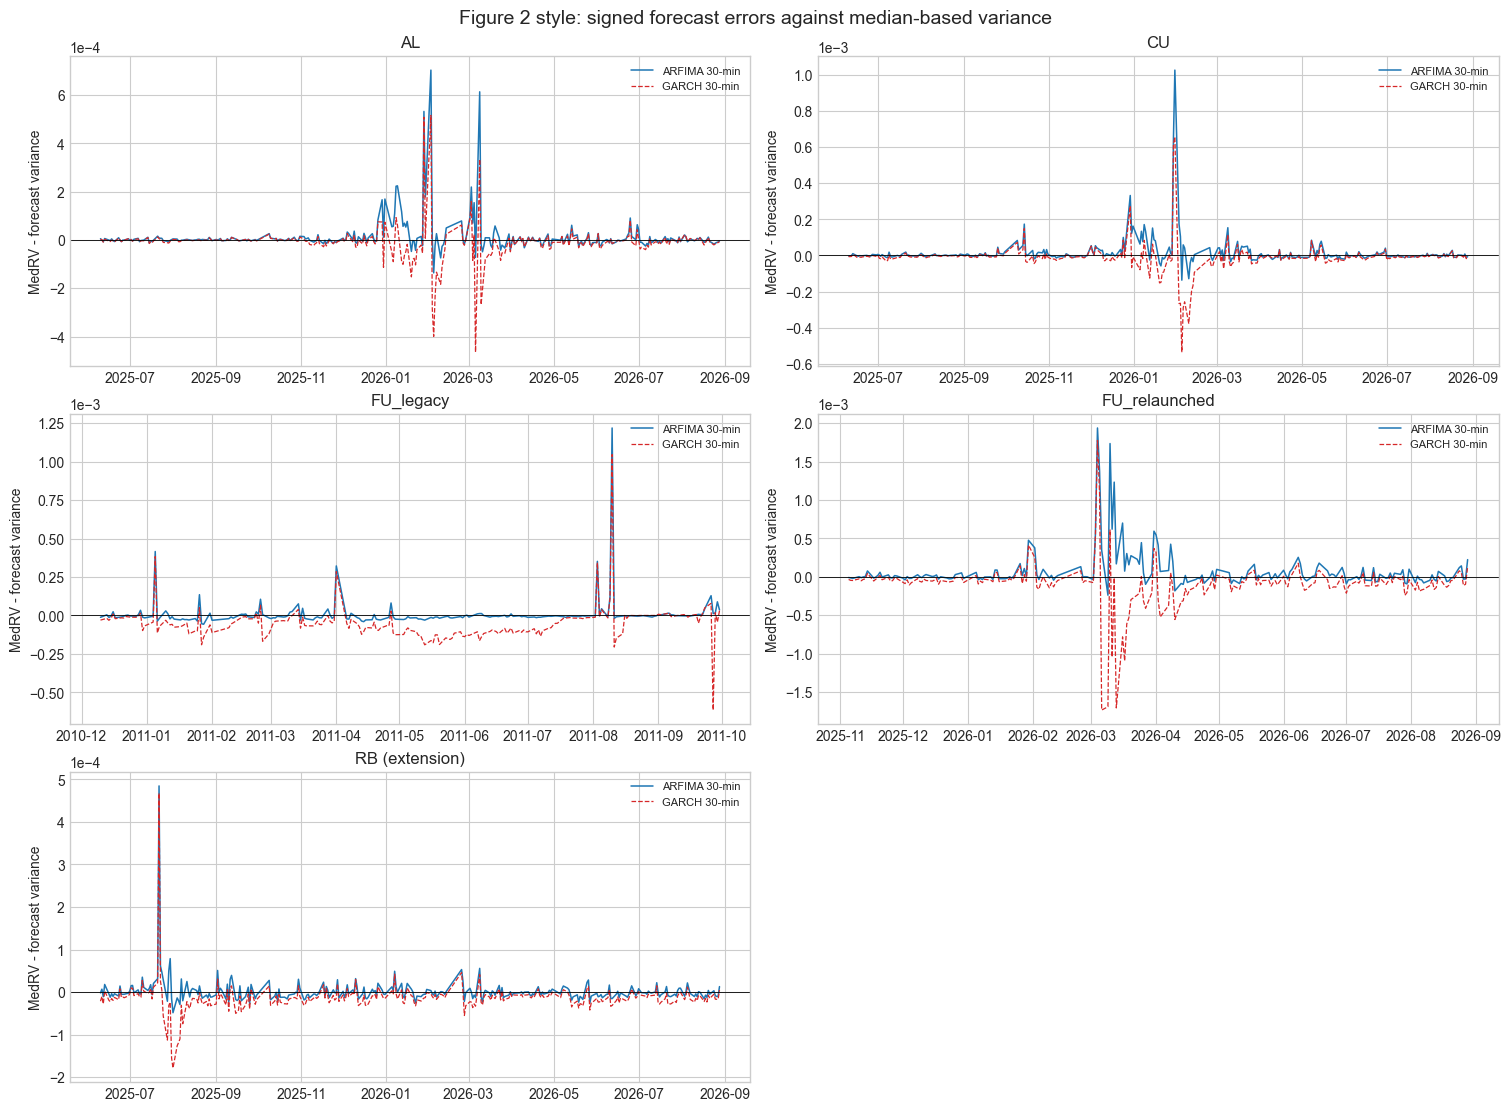

In [10]:
figure_model_ids = ["ARFIMA_30min", "GARCH_30min"]
figure_error_df = primary_loss_df.loc[
    primary_loss_df["proxy_id"].eq("MedRV")
    & primary_loss_df["model_id"].isin(figure_model_ids)
].copy()
assert len(figure_error_df) == 2 * int(sample_spec_df["oos_days"].sum())

figure_error_pivot_df = figure_error_df.pivot(
    index=["series_id", "forecast_date"],
    columns="model_id",
    values="forecast_error",
).reset_index()
figure_comparison_rows = []
for series_id, series_figure_df in figure_error_pivot_df.groupby(
    "series_id", observed=True, sort=False
):
    arfima_absolute_error = series_figure_df["ARFIMA_30min"].abs()
    garch_absolute_error = series_figure_df["GARCH_30min"].abs()
    figure_comparison_rows.append(
        {
            "series_id": series_id,
            "evaluation_days": len(series_figure_df),
            "ARFIMA_mean_absolute_error": arfima_absolute_error.mean(),
            "GARCH_mean_absolute_error": garch_absolute_error.mean(),
            "ARFIMA_smaller_absolute_error_share": (
                arfima_absolute_error < garch_absolute_error
            ).mean(),
        }
    )
figure_comparison_df = pd.DataFrame(figure_comparison_rows)
display(figure_comparison_df.round(8))

figure, axes = plt.subplots(
    3,
    2,
    figsize=(15, 11),
    sharex=False,
    constrained_layout=True,
)
axes = axes.ravel()
line_style_by_model = {
    "ARFIMA_30min": {"color": "#1f77b4", "linewidth": 1.1, "label": "ARFIMA 30-min"},
    "GARCH_30min": {"color": "#d62728", "linewidth": 0.9, "linestyle": "--", "label": "GARCH 30-min"},
}
for axis, series_id in zip(axes, series_order):
    series_error_df = figure_error_df.loc[
        figure_error_df["series_id"].eq(series_id)
    ].sort_values("forecast_date")
    for model_id in figure_model_ids:
        model_error_df = series_error_df.loc[
            series_error_df["model_id"].eq(model_id)
        ]
        axis.plot(
            model_error_df["forecast_date"],
            model_error_df["forecast_error"],
            **line_style_by_model[model_id],
        )
    axis.axhline(0.0, color="black", linewidth=0.6)
    title_suffix = " (extension)" if series_id == "RB" else ""
    axis.set_title(f"{series_id}{title_suffix}")
    axis.set_ylabel("MedRV - forecast variance")
    axis.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    axis.legend(loc="best", fontsize=8)
axes[-1].axis("off")
figure.suptitle(
    "Figure 2 style: signed forecast errors against median-based variance",
    fontsize=14,
)
plt.show()

## 10. 独立公式复核与验证门禁

In [11]:
manual_loss_row = primary_loss_df.loc[
    primary_loss_df["series_id"].eq("AL")
    & primary_loss_df["proxy_id"].eq("MedRV")
    & primary_loss_df["model_id"].eq("ARFIMA_30min")
].iloc[0]
manual_forecast_error = (
    manual_loss_row.true_variance - manual_loss_row.forecast_variance
)
manual_squared_error = manual_forecast_error**2

manual_rmsfe_slice_df = primary_loss_df.loc[
    primary_loss_df["series_id"].eq("AL")
    & primary_loss_df["proxy_id"].eq("RV_5min")
    & primary_loss_df["model_id"].eq("GARCH_15min")
]
manual_rmsfe = float(
    np.sqrt(
        np.mean(
            (
                manual_rmsfe_slice_df["true_variance"].to_numpy()
                - manual_rmsfe_slice_df["forecast_variance"].to_numpy()
            )
            ** 2
        )
    )
)
reported_manual_rmsfe = float(
    primary_rmsfe_df.loc[
        primary_rmsfe_df["series_id"].eq("AL")
        & primary_rmsfe_df["proxy_id"].eq("RV_5min")
        & primary_rmsfe_df["model_id"].eq("GARCH_15min"),
        "rmsfe",
    ].iloc[0]
)

validation_rows = []

def add_gate(gate, passed, evidence):
    validation_rows.append(
        {"gate": gate, "passed": bool(passed), "evidence": str(evidence)}
    )


add_gate(
    "latitude_environment",
    current_python == expected_python,
    current_python,
)
add_gate(
    "fixed_item09_identity_and_hashes",
    success_payload["manifest_sha256"] == sha256_file(manifest_path)
    and artifact_file_audit_df["integrity_passed"].all()
    and upstream_validation_df["passed"].all(),
    f"run_id={fixed_run_id}; files={len(artifact_file_audit_df)}; upstream_gates=27",
)
add_gate(
    "forecast_grid_and_oos_counts",
    len(forecast_panel_df) == 31_200
    and len(forecast_panel_df.loc[forecast_panel_df["is_primary"]]) == 19_500
    and len(forecast_panel_df.loc[~forecast_panel_df["is_primary"]]) == 11_700
    and oos_date_audit_df.set_index("series_id")["oos_days"].to_dict()
    == {"AL": 300, "CU": 300, "FU_legacy": 200, "FU_relaunched": 200, "RB": 300},
    "31,200 forecasts = 19,500 primary + 11,700 seasonality sensitivity",
)
add_gate(
    "model_information_precedes_target",
    forecast_panel_df["model_information_end"].lt(
        forecast_panel_df["forecast_date"]
    ).all(),
    "每个模型的信息截止日严格早于目标日",
)
add_gate(
    "forward_seasonality_isolated",
    forecast_panel_df["uses_forward_seasonality"].eq(
        forecast_panel_df["seasonality_variant"].eq("paper_full_sample")
    ).all()
    and forecast_panel_df.loc[
        forecast_panel_df["seasonality_variant"].eq("expanding_no_lookahead"),
        "seasonality_information_end",
    ].lt(
        forecast_panel_df.loc[
            forecast_panel_df["seasonality_variant"].eq("expanding_no_lookahead"),
            "forecast_date",
        ]
    ).all(),
    "论文全文样本因子只在 primary 行；无前视因子严格早于目标日",
)
add_gate(
    "three_month_contract_and_session_structure",
    len(target_session_audit_df) == 1_300
    and target_session_audit_df["session_count"].eq(3).all()
    and target_session_audit_df["minute_count"].eq(225).all()
    and target_day_df["delivery_year"].eq(target_delivery_period.year).all()
    and target_day_df["delivery_month"].eq(target_delivery_period.month).all(),
    "1,300 target days; +3 delivery month; 3 day sessions; 225 minutes",
)
add_gate(
    "minute_and_five_minute_structure",
    minute_read_audit_df["selected_day_minute_rows"].sum() == 1_300 * 225
    and minute_read_audit_df["five_minute_return_rows"].sum() == 1_300 * 45
    and minute_read_audit_df["maximum_session_span"].eq(1).all()
    and minute_read_audit_df["session_alignment_failures"].eq(0).all(),
    f"minutes={minute_read_audit_df['selected_day_minute_rows'].sum():,}; five-minute={minute_read_audit_df['five_minute_return_rows'].sum():,}",
)
add_gate(
    "session_open_return_anchors",
    minute_read_audit_df["session_open_anchors"].sum() == 1_300 * 3,
    "每个真实 Session 的首分钟使用本 Session open 作为收益基准",
)
add_gate(
    "three_proxies_complete_nonnegative",
    len(volatility_proxy_df) == 1_300
    and all(
        np.isfinite(volatility_proxy_df[proxy_column]).all()
        and volatility_proxy_df[proxy_column].ge(0).all()
        for proxy_column, _, _ in proxy_spec
    )
    and minute_read_audit_df["source_high_below_low_rows"].eq(0).all(),
    "1,300 days × RV/MedRV/Parkinson; finite and nonnegative",
)
add_gate(
    "loss_panel_complete",
    len(loss_panel_df) == 93_600
    and len(primary_loss_df) == 58_500
    and len(sensitivity_loss_df) == 35_100
    and np.isfinite(loss_panel_df["squared_forecast_error"]).all(),
    "93,600 losses = 58,500 primary + 35,100 sensitivity",
)
add_gate(
    "rmsfe_grid_complete",
    len(rmsfe_df) == 360
    and len(primary_rmsfe_df) == 225
    and len(sensitivity_rmsfe_df) == 135
    and np.isfinite(rmsfe_df["rmsfe"]).all()
    and rmsfe_df["rmsfe"].ge(0).all(),
    "5 series × 3 proxies × (15 primary + 9 sensitivity)",
)
add_gate(
    "sensitivity_extreme_forecast_diagnostic",
    np.isfinite(maximum_sensitivity_forecast)
    and maximum_sensitivity_forecast
    == forecast_panel_df.loc[
        ~forecast_panel_df["is_primary"], "forecast_variance"
    ].max()
    and sensitivity_extreme_forecast_df.iloc[0]["model_id"]
    == "IGARCH_15min_no_lookahead",
    (
        f"maximum={maximum_sensitivity_forecast:.6e}; "
        f"ratio_to_primary_max={sensitivity_to_primary_maximum_ratio:.6e}"
    ),
)
benchmark_minimum_check_df = benchmark_df.merge(
    primary_rmsfe_df.groupby(
        ["proxy_id", "series_id"], observed=True
    )["rmsfe"].min().rename("minimum_rmsfe").reset_index(),
    on=["proxy_id", "series_id"],
    validate="one_to_one",
)
add_gate(
    "lowest_rmsfe_benchmarks",
    len(benchmark_df) == 15
    and np.allclose(
        benchmark_minimum_check_df["rmsfe"],
        benchmark_minimum_check_df["minimum_rmsfe"],
        rtol=0.0,
        atol=0.0,
    ),
    "每个 series × proxy 恰好一个确定性最低 RMSFE 基准",
)
add_gate(
    "manual_error_sign_and_square",
    manual_forecast_error == manual_loss_row.forecast_error
    and manual_squared_error == manual_loss_row.squared_forecast_error,
    f"error={manual_forecast_error:.12e}; squared={manual_squared_error:.12e}",
)
add_gate(
    "manual_rmsfe_formula",
    np.isclose(manual_rmsfe, reported_manual_rmsfe, rtol=1e-15, atol=0.0),
    f"manual={manual_rmsfe:.12e}; grouped={reported_manual_rmsfe:.12e}",
)
add_gate(
    "figure2_model_and_proxy_scope",
    len(figure_error_df) == 2_600
    and set(figure_error_df["model_id"]) == set(figure_model_ids)
    and set(figure_error_df["proxy_id"]) == {"MedRV"},
    "1,300 days × ARFIMA/GARCH 30-min; median-based proxy",
)
add_gate(
    "fu_segments_and_rb_separate",
    target_day_df.loc[target_day_df["series_id"].eq("FU_legacy"), "forecast_date"].max()
    == pd.Timestamp("2011-09-30")
    and target_day_df.loc[
        target_day_df["series_id"].eq("FU_relaunched"), "forecast_date"
    ].min()
    > pd.Timestamp("2020-01-02")
    and benchmark_df.loc[benchmark_df["series_id"].eq("RB")].shape[0] == 3,
    "FU 两段不连接；RB 三个代理均独立选基准",
)

validation_df = pd.DataFrame(validation_rows)
display(validation_df)
assert validation_df["passed"].all(), validation_df.loc[~validation_df["passed"]]
print(f"全部 {len(validation_df)} 项门禁通过。")

,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,fixed_item09_identity_and_hashes,True,run_id=eaf4757d3488c2b7; files=4; upstream_gates=27
2,forecast_grid_and_oos_counts,True,"31,200 forecasts = 19,500 primary + 11,700 seasonality sensitivity"
3,model_information_precedes_target,True,每个模型的信息截止日严格早于目标日
4,forward_seasonality_isolated,True,论文全文样本因子只在 primary 行；无前视因子严格早于目标日
5,three_month_contract_and_session_structure,True,"1,300 target days; +3 delivery month; 3 day sessions; 225 minutes"
6,minute_and_five_minute_structure,True,"minutes=292,500; five-minute=58,500"
7,session_open_return_anchors,True,每个真实 Session 的首分钟使用本 Session open 作为收益基准
8,three_proxies_complete_nonnegative,True,"1,300 days × RV/MedRV/Parkinson; finite and nonnegative"
9,loss_panel_complete,True,"93,600 losses = 58,500 primary + 35,100 sensitivity"


全部 17 项门禁通过。


## 11. 结果解释与限制

In [12]:
benchmark_class_summary_df = (
    benchmark_df.groupby(["proxy_id", "model_label"], observed=True)
    .size()
    .rename("benchmark_count")
    .reset_index()
)
benchmark_frequency_summary_df = (
    benchmark_df.groupby(["proxy_id", "interval_label"], observed=True)
    .size()
    .rename("benchmark_count")
    .reset_index()
)
paper_series_benchmark_df = benchmark_df.loc[
    ~benchmark_df["series_id"].eq("RB")
].copy()
rb_benchmark_df = benchmark_df.loc[benchmark_df["series_id"].eq("RB")].copy()

display(Markdown("### 最低误差模型类别分布"))
display(benchmark_class_summary_df)
display(Markdown("### 最低误差采样频率分布"))
display(benchmark_frequency_summary_df)
display(Markdown("### 论文品种（FU 两段独立）"))
display(paper_series_benchmark_df.round({"rmsfe": 10, "rmsfe_x1e5": 4}))
display(Markdown("### RB 扩展"))
display(rb_benchmark_df.round({"rmsfe": 10, "rmsfe_x1e5": 4}))

arfima_benchmark_count = int(benchmark_df["model_label"].eq("ARFIMA").sum())
daily_benchmark_count = int(benchmark_df["interval_label"].eq("Daily").sum())
no_lookahead_win_count = int(
    seasonality_sensitivity_df["no_lookahead_minus_paper_rmsfe"].lt(0).sum()
)
extreme_sensitivity_row = sensitivity_extreme_forecast_df.iloc[0]
display(
    Markdown(
        f"""**本湖仓样本结论。** 15 个“研究序列 × 方差代理”组合中，ARFIMA 取得 {arfima_benchmark_count} 个最低 RMSFE，日频 GARCH 家族取得 {daily_benchmark_count} 个最低 RMSFE。九个盘中 GARCH 家族模型在五个序列和三个代理上的 135 组配对中，无前视季节因子版本有 {no_lookahead_win_count} 组 RMSFE 更低。模型排名只能解释为当前 JQData 日盘样本中的预测表现，不能机械外推为论文 GTA 样本结论。"""
    )
)

display(
    Markdown(
        f"""**限制。** 三个代理都不是潜在真实条件方差本身；RMSFE 对极端平方误差敏感。无前视敏感性中，`{extreme_sensitivity_row['series_id']} / {extreme_sensitivity_row['model_id']} / {extreme_sensitivity_row['forecast_date']:%Y-%m-%d}` 的预测方差达到 `{extreme_sensitivity_row['forecast_variance']:.6e}`，约为 primary 最大预测的 `{sensitivity_to_primary_maximum_ratio:.3e}` 倍；这表明该敏感性流发生数值或尺度不稳定，不能用总体胜负计数掩盖。论文全文样本季节因子含明确前视信息，所以主结果仍与无前视结果并列展示，但第 11–12 项论文基线检验只使用 15 个 primary 模型。日频模型预测的是 Session 内日收益方差，不含隔夜与 Session 间跳空。最低 RMSFE 只是后续检验的候选基准，并不单独证明统计显著优越。"""
    )
)

### 最低误差模型类别分布

,proxy_id,model_label,benchmark_count
0,MedRV,ARFIMA,2
1,MedRV,FIGARCH,3
2,Parkinson,FIGARCH,3
3,Parkinson,GARCH,2
4,RV_5min,ARFIMA,1
5,RV_5min,FIGARCH,2
6,RV_5min,GARCH,2


### 最低误差采样频率分布

,proxy_id,interval_label,benchmark_count
0,MedRV,15-min,2
1,MedRV,30-min,1
2,MedRV,60-min,2
3,Parkinson,15-min,1
4,Parkinson,60-min,3
5,Parkinson,Daily,1
6,RV_5min,15-min,2
7,RV_5min,30-min,2
8,RV_5min,Daily,1


### 论文品种（FU 两段独立）

,proxy_id,series_id,model_id,model_label,interval_label,rmsfe,rmsfe_x1e5,evaluation_days
0,MedRV,AL,FIGARCH_60min,FIGARCH,60-min,0.000069,6.9404,300
1,MedRV,CU,FIGARCH_30min,FIGARCH,30-min,0.000067,6.6592,300
2,MedRV,FU_legacy,ARFIMA_15min,ARFIMA,15-min,0.000100,10.0231,200
3,MedRV,FU_relaunched,FIGARCH_60min,FIGARCH,60-min,0.000261,26.1483,200
5,Parkinson,AL,GARCH_15min,GARCH,15-min,0.000102,10.2303,300
6,Parkinson,CU,FIGARCH_60min,FIGARCH,60-min,0.000139,13.8702,300
7,Parkinson,FU_legacy,FIGARCH_Daily,FIGARCH,Daily,0.000079,7.9302,200
8,Parkinson,FU_relaunched,GARCH_60min,GARCH,60-min,0.000492,49.1803,200
10,RV_5min,AL,GARCH_15min,GARCH,15-min,0.000080,8.0397,300
11,RV_5min,CU,FIGARCH_30min,FIGARCH,30-min,0.000072,7.2173,300


### RB 扩展

,proxy_id,series_id,model_id,model_label,interval_label,rmsfe,rmsfe_x1e5,evaluation_days
4,MedRV,RB,ARFIMA_15min,ARFIMA,15-min,0.000032,3.1849,300
9,Parkinson,RB,FIGARCH_60min,FIGARCH,60-min,0.000040,3.9753,300
14,RV_5min,RB,ARFIMA_15min,ARFIMA,15-min,0.000054,5.3546,300


**本湖仓样本结论。** 15 个“研究序列 × 方差代理”组合中，ARFIMA 取得 3 个最低 RMSFE，日频 GARCH 家族取得 2 个最低 RMSFE。九个盘中 GARCH 家族模型在五个序列和三个代理上的 135 组配对中，无前视季节因子版本有 58 组 RMSFE 更低。模型排名只能解释为当前 JQData 日盘样本中的预测表现，不能机械外推为论文 GTA 样本结论。

**限制。** 三个代理都不是潜在真实条件方差本身；RMSFE 对极端平方误差敏感。无前视敏感性中，`FU_legacy / IGARCH_15min_no_lookahead / 2011-08-31` 的预测方差达到 `1.208743e+09`，约为 primary 最大预测的 `1.882e+11` 倍；这表明该敏感性流发生数值或尺度不稳定，不能用总体胜负计数掩盖。论文全文样本季节因子含明确前视信息，所以主结果仍与无前视结果并列展示，但第 11–12 项论文基线检验只使用 15 个 primary 模型。日频模型预测的是 Session 内日收益方差，不含隔夜与 Session 间跳空。最低 RMSFE 只是后续检验的候选基准，并不单独证明统计显著优越。